In [459]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from IPython.display import clear_output

In [460]:
# Load the dataset
df_airbnb = pd.read_csv('airbnb.csv')
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,11/19/2018,0.10,1,0


In [461]:
# Check for Nan values
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [462]:
df_airbnb.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [463]:
# Fill Nan values with 0
df_airbnb["reviews_per_month"] = df_airbnb["reviews_per_month"].fillna(0)

df_airbnb.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [464]:
# Create DataFrame with features used for clustering
features = [
    "neighbourhood_group", "room_type", "price", "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365"
    ]

In [465]:
data = df_airbnb[features].copy()

data.head()

,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Private room,149,1,9,0.21,6,365
1,Manhattan,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Private room,150,3,0,0.00,1,365
3,Brooklyn,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,Entire home/apt,80,10,9,0.10,1,0


In [466]:
data.isnull().sum()

neighbourhood_group               0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [467]:
# Remove outlier
data.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**Note:**
- Extreme outliers were observed in variables such as price, number of reviews, review per month counts, and host listings count. These were removed using the 99th percentile threshold to improve clustering stability.

In [468]:
# Remove extreme outliers using the 99th percentile
data = data[
    (data['price'] < data['price'].quantile(0.99)) &
    (data['minimum_nights'] < data['minimum_nights'].quantile(0.99)) &
    (data['number_of_reviews'] < data['number_of_reviews'].quantile(0.99)) &
    (data['reviews_per_month'] < data['reviews_per_month'].quantile(0.99)) &
    (data['calculated_host_listings_count'] < data['calculated_host_listings_count'].quantile(0.99))
]

data.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000
mean,136.236246,5.621373,20.742144,1.002007,3.941261,108.219802
std,102.539854,8.227813,35.615693,1.347339,12.528928,130.071966
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,68.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,103.000000,3.000000,5.000000,0.370000,1.000000,37.000000
75%,175.000000,5.000000,23.000000,1.500000,2.000000,212.000000
max,795.000000,44.000000,213.000000,6.790000,121.000000,365.000000


In [469]:
data.isnull().sum()

neighbourhood_group               0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

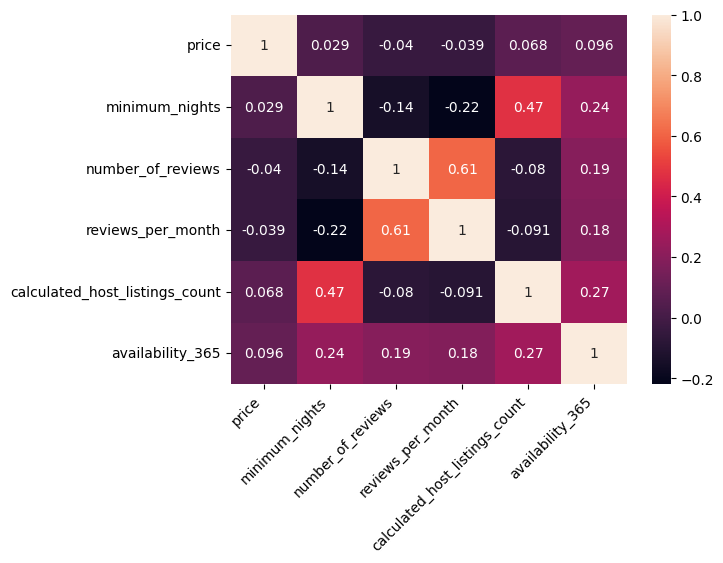

In [470]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = data.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True)

plt.xticks(rotation=45, ha='right')
plt.show()

=> Dimensionality reduction was not required for clustering, as the dataset contains a small number of features with low multicollinearity. 

In [471]:
# Encoding categorical data
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

categorical_cols = ['neighbourhood_group', 'room_type']

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first'
)

encoded = encoder.fit_transform(data[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=data.index
)

data = pd.concat(
    [
        data.drop(columns=categorical_cols),
        encoded_df
    ],
    axis=1
)

data.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,149,1,9,0.21,6,365,1.0,0.0,0.0,0.0,1.0,0.0
1,225,1,45,0.38,2,355,0.0,1.0,0.0,0.0,0.0,0.0
2,150,3,0,0.00,1,365,0.0,1.0,0.0,0.0,1.0,0.0
4,80,10,9,0.10,1,0,0.0,1.0,0.0,0.0,0.0,0.0
5,200,3,74,0.59,1,129,0.0,1.0,0.0,0.0,0.0,0.0


### K-mean Clustering
1. Scale the data
2. Initialize random centroids
3. Label each data point
4. Update centroids
5. Repeat step 3 and step 4 until centroids stop changing

In [472]:
# Step 1: Scale the data
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(
    data_scaled, 
    columns=data.columns,
    index=data.index
    )

data_scaled.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,0.187421,0.000000,0.042254,0.030928,0.041667,1.000000,1.0,0.0,0.0,0.0,1.0,0.0
1,0.283019,0.000000,0.211268,0.055965,0.008333,0.972603,0.0,1.0,0.0,0.0,0.0,0.0
2,0.188679,0.046512,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,1.0,0.0
4,0.100629,0.209302,0.042254,0.014728,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0
5,0.251572,0.046512,0.347418,0.086892,0.000000,0.353425,0.0,1.0,0.0,0.0,0.0,0.0


In [473]:
data_scaled.describe()  

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
count,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000
mean,0.171366,0.107474,0.097381,0.147571,0.024511,0.296493,0.419759,0.433663,0.116207,0.007706,0.464270,0.024193
std,0.128981,0.191344,0.167210,0.198430,0.104408,0.356362,0.493525,0.495585,0.320477,0.087443,0.498727,0.153649
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.085535,0.000000,0.004695,0.005891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.129560,0.046512,0.023474,0.054492,0.000000,0.101370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.220126,0.093023,0.107981,0.220913,0.008333,0.580822,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [474]:
# Step 2: Intialize random centroids
def random_centroids(data, k, random_state=42):
    return data.sample(n=k, random_state=random_state).reset_index(drop=True)

centroids = random_centroids(data_scaled, 5)

centroids

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,0.069182,0.023256,0.197183,0.153166,0.000000,0.323288,0.0,0.0,1.0,0.0,1.0,0.0
1,0.213836,0.093023,0.061033,0.044183,0.000000,0.010959,0.0,1.0,0.0,0.0,0.0,0.0
2,0.182390,0.046512,0.004695,0.092784,0.041667,1.000000,0.0,1.0,0.0,0.0,1.0,0.0
3,0.050314,0.023256,0.014085,0.061856,0.000000,0.052055,0.0,1.0,0.0,0.0,1.0,0.0
4,0.201258,0.000000,0.004695,0.147275,0.058333,0.997260,1.0,0.0,0.0,0.0,1.0,0.0


In [475]:
# Step 3: Label each data point
def get_labels(data, centroids):
    distances = centroids.apply(
        lambda x: np.sqrt(((data - x)**2).sum(axis=1)), axis=1).T
    return distances.idxmin(axis=1)

labels = get_labels(data_scaled, centroids)

In [476]:
labels.value_counts()

4    16505
1    16171
3     6058
0     5676
2     2050
Name: count, dtype: int64

In [477]:
# Step 4: Update centroids
def update_centroids(data, labels):
    return data.groupby(labels).mean()

new_centroids = update_centroids(data_scaled, labels)

new_centroids

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,0.117009,0.081789,0.107845,0.194400,0.025411,0.390385,0.000000,0.000000,0.951198,0.009161,0.615046,0.033122
1,0.246124,0.146165,0.073244,0.109015,0.041151,0.241348,0.193000,0.770886,0.000000,0.010760,0.000000,0.035496
2,0.152356,0.115043,0.141523,0.175113,0.043565,0.845977,0.000000,0.905854,0.000000,0.026341,0.989268,0.008293
3,0.123204,0.065668,0.086984,0.138523,0.006124,0.092341,0.000000,0.961538,0.000000,0.006108,1.000000,0.000000
4,0.136854,0.092803,0.115765,0.169143,0.012279,0.324916,0.992487,0.000000,0.000000,0.002484,0.605453,0.020903


In [478]:
# Compute sse to construct Elbow plot
def compute_sse(data, labels, centroids):
    sse = 0
    for i in range(len(centroids)):
        cluster_points = data[labels == i]
        if len(cluster_points) > 0:
            sse += ((cluster_points - centroids.iloc[i]) ** 2).sum().sum()
    return sse


In [479]:
# Step 5: Repeat step 3 and step 4 until centroids stop changing
def plot_clusters(data, labels, centroids, iteration):
    pca = PCA(n_components=2)
    data_2D = pca.fit_transform(data)
    centroids_2D = pca.transform(centroids)
    clear_output(wait=True)
    plt.title(f"Iteration {iteration}")
    plt.scatter(x=data_2D[:, 0], y=data_2D[:, 1], c=labels)
    plt.scatter(x=centroids_2D[:,0], y=centroids_2D[:,1])
    plt.show()

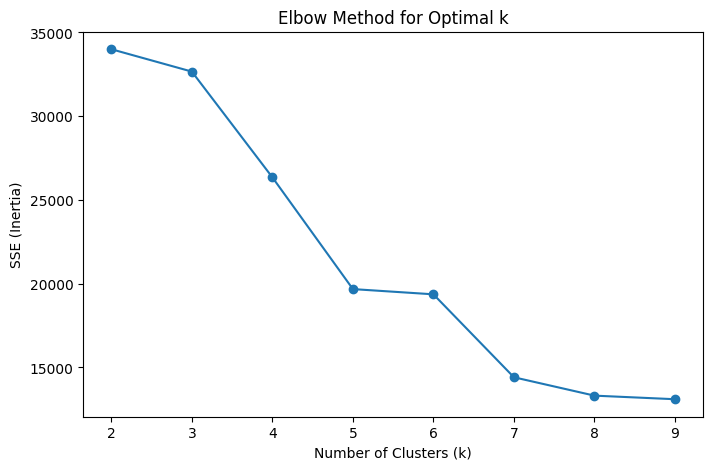

In [480]:
# Construct the Elbow Plot
k_values = range(2, 10)
sse_values = []

for k in k_values:
    
    # Initialize centroid
    centroids = random_centroids(data_scaled, k, random_state=42)

    # Repeat until centroids stop changing
    for _ in range(100):
        labels = get_labels(data_scaled, centroids)
        new_c = update_centroids(data_scaled, labels)

        if np.allclose(new_c.values, centroids.values, atol=1e-6):
            break

        centroids = new_c

    # Compute SSE for this k
    labels = get_labels(data_scaled, centroids)
    sse = compute_sse(data_scaled, labels, centroids)

    sse_values.append(sse)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [ ]:
k = 7
max_iterations = 100

# Initialize centroids
centroids = random_centroids(data_scaled, k, random_state=42)

# Repeat until centroids stop changing
for iteration in range(max_iterations):
    labels = get_labels(data_scaled, centroids)
    new_centroids = update_centroids(data_scaled, labels)

    if np.allclose(new_centroids.values, centroids.values, atol=1e-6):
        print(f"Converged at iteration {iteration}")
        centroids = new_centroids
        break

    centroids = new_centroids

# Get final labels again based on final centroids
labels = get_labels(data_scaled, centroids)

# Calculate final SSE
final_sse = compute_sse(data_scaled, labels, centroids)

print(f"Final SSE: {final_sse:.2f}")
print(labels.value_counts())

Final SSE: 23780.87
6    13321
1    12931
4     6424
0     5666
5     3056
3     3017
2     2045
Name: count, dtype: int64


In [482]:
final_centroids = centroids.copy()
final_labels = labels.copy()

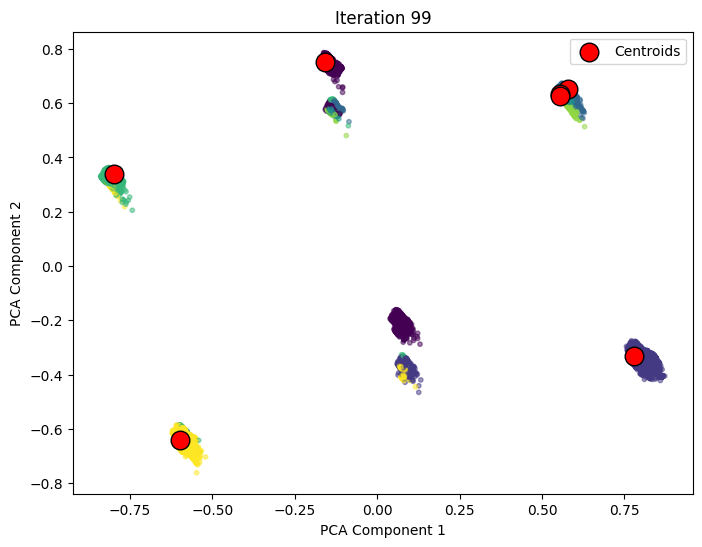

In [483]:
def plot_clusters(data, labels, centroids, iteration):
    pca = PCA(n_components=2)
    data_2D = pca.fit_transform(data)
    centroids_2D = pca.transform(centroids)

    clear_output(wait=True)

    plt.figure(figsize=(8, 6))
    plt.title(f"Iteration {iteration}")

    plt.scatter(
        x=data_2D[:, 0],
        y=data_2D[:, 1],
        c=labels,
        cmap='viridis',
        alpha=0.5,
        s=10
    )

    plt.scatter(
        x=centroids_2D[:, 0],
        y=centroids_2D[:, 1],
        s=180,
        c='red',
        edgecolors='black',
        label='Centroids'
    )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.show()

plot_clusters(data_scaled, final_labels, final_centroids, iteration)